Training e-prop for precise spike timing...
Target output spike time: 80.0ms
Hidden neuron will fire at: ~51ms
Gap to bridge: ~29ms



WARNING    Removing unsupported flag '-march=native' from compiler flags. [brian2.codegen.cpp_prefs]


Done! Plotting results...


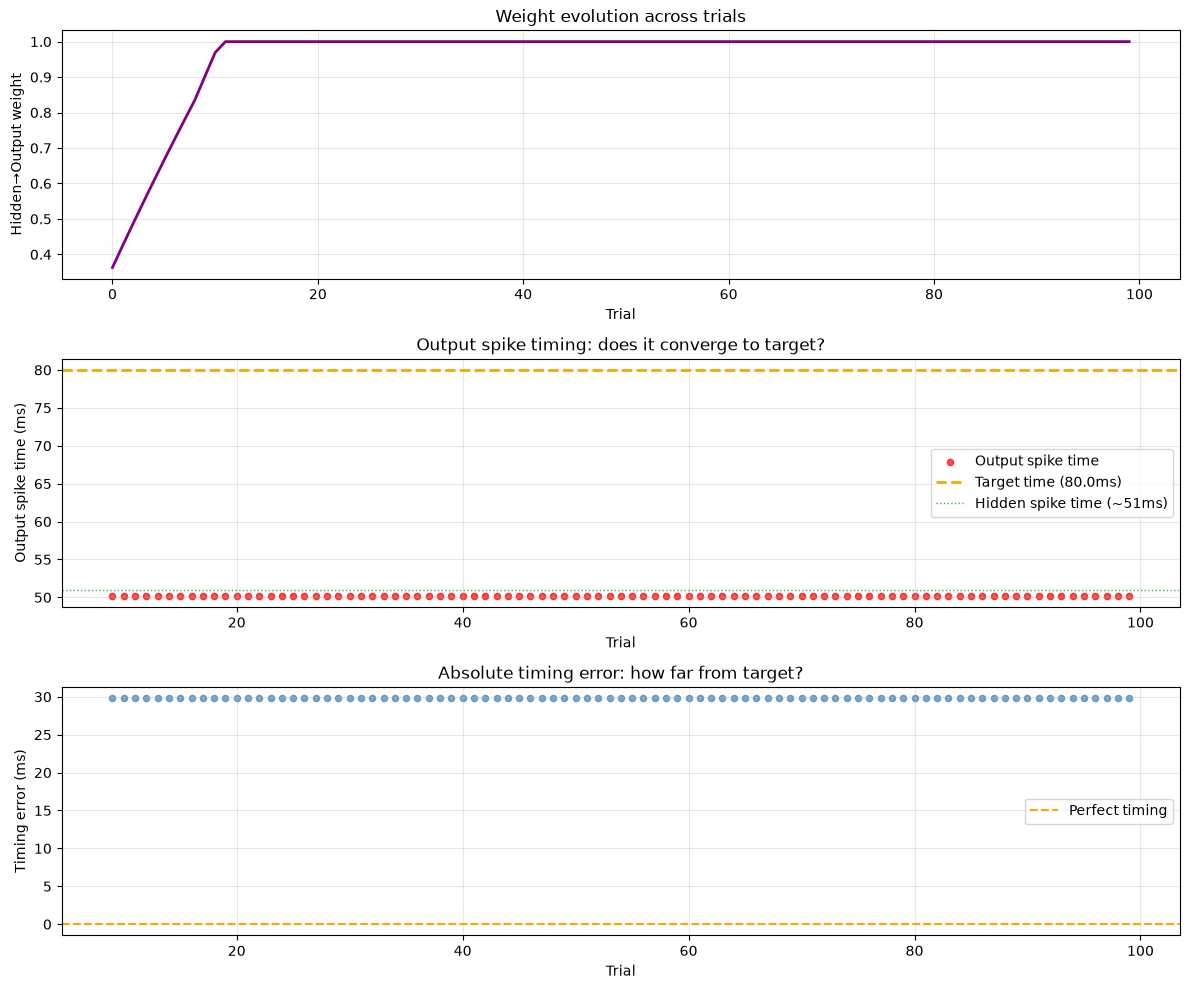


Starting weight: 0.3000
Final weight: 1.0000
Trials where output fired: 91/100
Mean output spike time (last 20 firing trials): 50.20ms
Target time: 80.0ms
Mean timing error (last 20 trials): 29.80ms


In [1]:
from brian2 import *
import numpy as np
import matplotlib.pyplot as plt

start_scope()

# E-PROP NOTEBOOK 02: PRECISE SPIKE TIMING
# Notebook 01 trained the output to fire "at some point"
# This notebook trains it to fire at a SPECIFIC target time
# The learning signal now encodes when the error occurred, not just if it occurred

# Key difference from notebook 01:
# Learning signal = voltage error evaluated at the TARGET TIME specifically
# If output fires too early → negative signal at target → the weight decreases
# If output fires too late or not at all → positive signal at target → the weight increases
# If output fires exactly at target → zero signal → the weight is not updated

tau_mem = 10*ms
tau_trace = 20*ms
tau_out = 20*ms
learning_rate = 0.3
n_trials = 100

# Target spike time is the time we want the output to fire at
target_time = 80*ms  # deliberately different from when hidden fires

weights = []
output_spike_times = []
w = 0.3

print("Training e-prop for precise spike timing...")
print(f"Target output spike time: {target_time/ms}ms")
print(f"Hidden neuron will fire at: ~51ms")
print(f"Gap to bridge: ~29ms\n")

for trial in range(n_trials):
    start_scope()
    
    # Input fires at t=50ms
    input_neuron = SpikeGeneratorGroup(1, [0], [50]*ms)
    
    eqs_hidden = '''
    dv/dt = -v/tau_mem : 1
    detrace/dt = -etrace/tau_trace : 1
    '''
    hidden = NeuronGroup(1, eqs_hidden,
                        threshold='v>0.8',
                        reset='v=0; etrace+=1.0',
                        method='exact')
    hidden.v = 0
    hidden.etrace = 0
    
    eqs_out = '''
    dv/dt = -v/tau_out : 1
    '''
    output = NeuronGroup(1, eqs_out,
                        threshold='v>0.8', reset='v=0',
                        method='exact')
    output.v = 0
    
    S_in = Synapses(input_neuron, hidden, 'w_in:1', on_pre='v_post += w_in')
    S_in.connect()
    S_in.w_in = 0.9
    
    S_out = Synapses(hidden, output, 'w_out:1', on_pre='v_post += w_out')
    S_out.connect()
    S_out.w_out = w
    
    spike_mon_h = SpikeMonitor(hidden)
    spike_mon_o = SpikeMonitor(output)
    voltage_mon_o = StateMonitor(output, 'v', record=True)
    trace_mon = StateMonitor(hidden, 'etrace', record=True)
    
    run(200*ms)
    
    # PRECISE TIMING LEARNING SIGNAL
    # Evaluate error at the target time specifically
    target_idx = int(target_time/defaultclock.dt)
    
    actual_voltage_at_target = voltage_mon_o.v[0][target_idx]
    target_voltage = 1.0  # want voltage at threshold at target time
    
    # Learning signal at target time
    learning_signal = target_voltage - actual_voltage_at_target
    
    # Eligibility trace at target time
    trace_at_target = trace_mon.etrace[0][target_idx]
    
    # Weight update
    delta_w = learning_rate * learning_signal * trace_at_target
    w = np.clip(w + delta_w, 0, 1)
    
    weights.append(w)
    
    # Record when output actually fired
    if len(spike_mon_o.t) > 0:
        output_spike_times.append(spike_mon_o.t[0]/ms)
    else:
        output_spike_times.append(None)

print("Done! Plotting results...")

# Plot
fig, (ax1, ax2, ax3) = plt.subplots(3, 1, figsize=(12, 10))

# Weight evolution
ax1.plot(range(n_trials), weights, color='purple', linewidth=2)
ax1.set_xlabel('Trial')
ax1.set_ylabel('Hidden→Output weight')
ax1.set_title('Weight evolution across trials')
ax1.grid(True, alpha=0.3)

# Output spike times
fired_trials = [(i, t) for i, t in enumerate(output_spike_times) if t is not None]
silent_trials = [i for i, t in enumerate(output_spike_times) if t is None]

if fired_trials:
    trials, times = zip(*fired_trials)
    ax2.scatter(trials, times, color='red', s=20, alpha=0.7, label='Output spike time')
ax2.axhline(y=target_time/ms, color='orange', linestyle='--', 
            linewidth=2, label=f'Target time ({target_time/ms}ms)')
ax2.axhline(y=51, color='green', linestyle=':', 
            linewidth=1, alpha=0.7, label='Hidden spike time (~51ms)')
ax2.set_xlabel('Trial')
ax2.set_ylabel('Output spike time (ms)')
ax2.set_title('Output spike timing: does it converge to target?')
ax2.legend()
ax2.grid(True, alpha=0.3)

# Timing error over trials
timing_errors = []
for t in output_spike_times:
    if t is not None:
        timing_errors.append(abs(t - target_time/ms))
    else:
        timing_errors.append(None)

error_values = [e for e in timing_errors if e is not None]
error_trials = [i for i, e in enumerate(timing_errors) if e is not None]

if error_values:
    ax3.scatter(error_trials, error_values, color='steelblue', s=20, alpha=0.7)
    ax3.axhline(y=0, color='orange', linestyle='--', label='Perfect timing')
ax3.set_xlabel('Trial')
ax3.set_ylabel('Timing error (ms)')
ax3.set_title('Absolute timing error: how far from target?')
ax3.legend()
ax3.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Summary
fired = [t for t in output_spike_times if t is not None]
print(f"\nStarting weight: 0.3000")
print(f"Final weight: {weights[-1]:.4f}")
print(f"Trials where output fired: {len(fired)}/{n_trials}")
if fired:
    late_fired = [t for t in fired[-20:] if t is not None]
    print(f"Mean output spike time (last 20 firing trials): {np.mean(late_fired):.2f}ms")
    print(f"Target time: {target_time/ms}ms")
    print(f"Mean timing error (last 20 trials): {abs(np.mean(late_fired) - target_time/ms):.2f}ms")

Training with timing-aware learning signal...
Done!


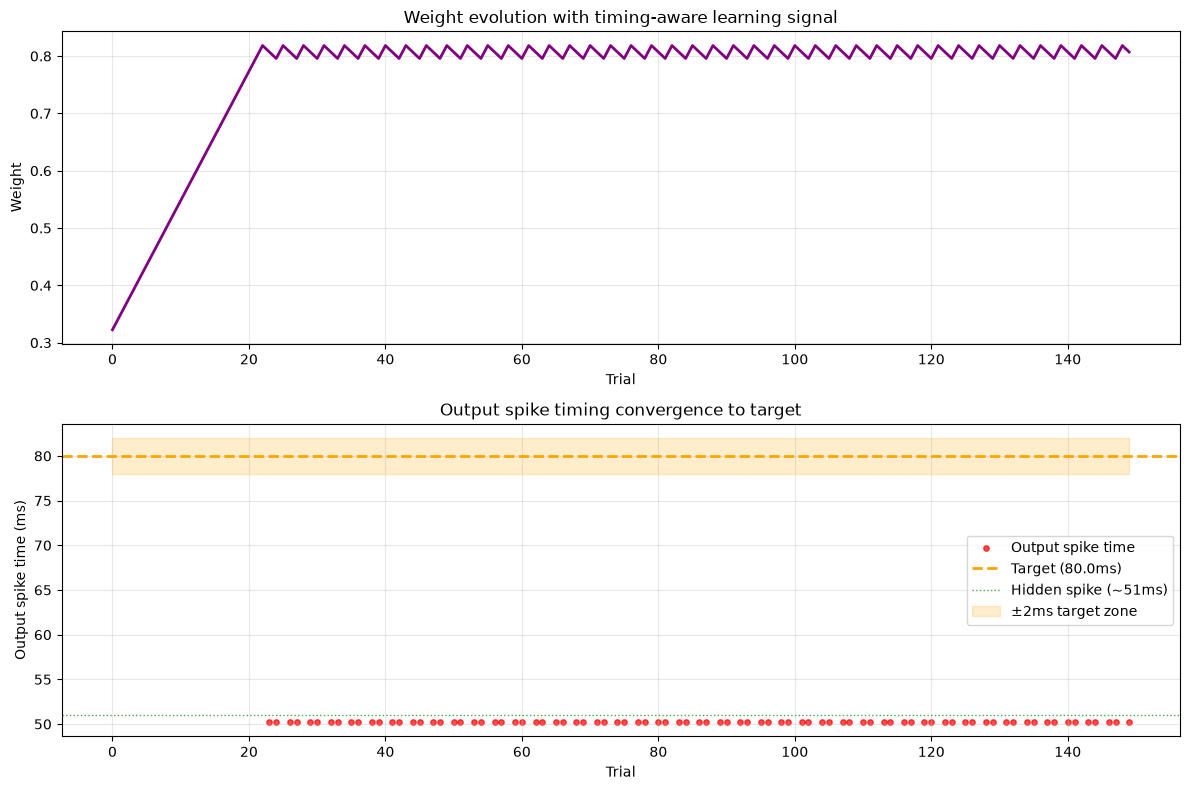


Final weight: 0.8071
Trials fired: 85/150
Trials in target zone (±2ms): 0/150
Mean spike time (last 20 trials): 50.20ms
Target: 80.0ms
Mean error (last 20 trials): 29.80ms


In [2]:
start_scope()

tau_mem = 10*ms
tau_trace = 20*ms
tau_out = 20*ms
learning_rate = 0.1
n_trials = 150

target_time = 80*ms

weights = []
output_spike_times = []
w = 0.3

print("Training with timing-aware learning signal...")

for trial in range(n_trials):
    start_scope()
    
    input_neuron = SpikeGeneratorGroup(1, [0], [50]*ms)
    
    eqs_hidden = '''
    dv/dt = -v/tau_mem : 1
    detrace/dt = -etrace/tau_trace : 1
    '''
    hidden = NeuronGroup(1, eqs_hidden,
                        threshold='v>0.8',
                        reset='v=0; etrace+=1.0',
                        method='exact')
    hidden.v = 0
    hidden.etrace = 0
    
    eqs_out = '''
    dv/dt = -v/tau_out : 1
    '''
    output = NeuronGroup(1, eqs_out,
                        threshold='v>0.8', reset='v=0',
                        method='exact')
    output.v = 0
    
    S_in = Synapses(input_neuron, hidden, 'w_in:1', on_pre='v_post += w_in')
    S_in.connect()
    S_in.w_in = 0.9
    
    S_out = Synapses(hidden, output, 'w_out:1', on_pre='v_post += w_out')
    S_out.connect()
    S_out.w_out = w
    
    spike_mon_h = SpikeMonitor(hidden)
    spike_mon_o = SpikeMonitor(output)
    trace_mon = StateMonitor(hidden, 'etrace', record=True)
    
    run(200*ms)
    
    # TIMING-AWARE LEARNING SIGNAL
    target_idx = int(target_time/defaultclock.dt)
    trace_at_target = trace_mon.etrace[0][target_idx]
    
    if len(spike_mon_o.t) == 0:
        # Output never fired — strongly encourage firing
        learning_signal = 1.0
        
    else:
        first_spike = spike_mon_o.t[0]
        timing_error = (first_spike - target_time) / ms
        
        if timing_error < -2:
            # Fired too early — penalize
            learning_signal = -0.5
        elif abs(timing_error) <= 2:
            # Fired at target — perfect, no update needed
            learning_signal = 0.0
        else:
            # Fired too late — encourage earlier firing
            learning_signal = 0.3
    
    delta_w = learning_rate * learning_signal * trace_at_target
    w = np.clip(w + delta_w, 0, 1)
    
    weights.append(w)
    if len(spike_mon_o.t) > 0:
        output_spike_times.append(spike_mon_o.t[0]/ms)
    else:
        output_spike_times.append(None)

print("Done!")

# Plot
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 8))

ax1.plot(range(n_trials), weights, color='purple', linewidth=2)
ax1.set_xlabel('Trial')
ax1.set_ylabel('Weight')
ax1.set_title('Weight evolution with timing-aware learning signal')
ax1.grid(True, alpha=0.3)

fired_trials = [(i, t) for i, t in enumerate(output_spike_times) if t is not None]
if fired_trials:
    trials, times = zip(*fired_trials)
    ax2.scatter(trials, times, color='red', s=15, alpha=0.7, label='Output spike time')
ax2.axhline(y=target_time/ms, color='orange', linestyle='--',
            linewidth=2, label=f'Target ({target_time/ms}ms)')
ax2.axhline(y=51, color='green', linestyle=':',
            linewidth=1, alpha=0.7, label='Hidden spike (~51ms)')
ax2.fill_between(range(n_trials), 
                  target_time/ms - 2, target_time/ms + 2,
                  alpha=0.2, color='orange', label='±2ms target zone')
ax2.set_xlabel('Trial')
ax2.set_ylabel('Output spike time (ms)')
ax2.set_title('Output spike timing convergence to target')
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Summary
fired = [t for t in output_spike_times if t is not None]
in_target_zone = [t for t in fired if abs(t - target_time/ms) <= 2]
print(f"\nFinal weight: {weights[-1]:.4f}")
print(f"Trials fired: {len(fired)}/{n_trials}")
print(f"Trials in target zone (±2ms): {len(in_target_zone)}/{n_trials}")
if fired:
    late_fired = [t for t in fired[-20:]]
    print(f"Mean spike time (last 20 trials): {np.mean(late_fired):.2f}ms")
    print(f"Target: {target_time/ms}ms")
    print(f"Mean error (last 20 trials): {np.mean([abs(t - target_time/ms) for t in late_fired]):.2f}ms")

Training with delay-line architecture...
Input -> Hidden (fast) -> Delay neuron (slow) -> Output

Done!
Delay neuron fired at: [50.2] (should be well after 50ms)


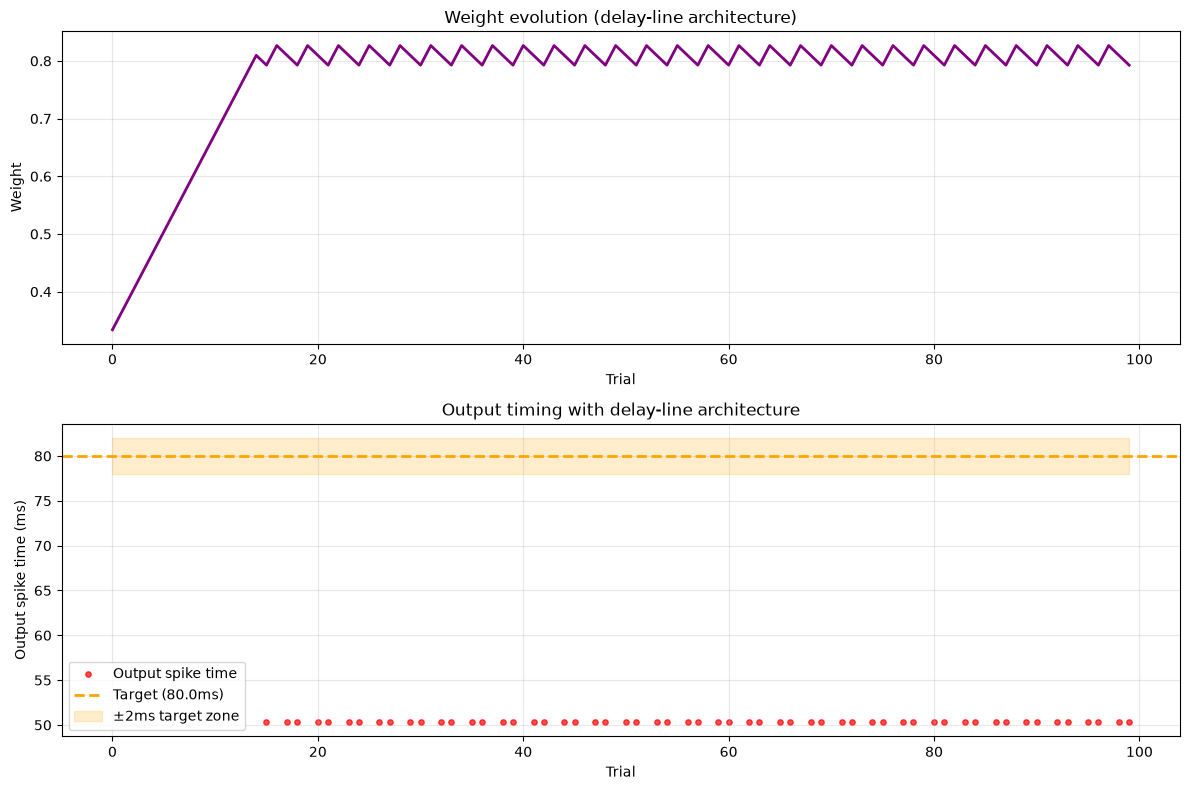


Final weight: 0.7926
Trials fired: 57/100
Mean spike time (last 20 trials): 50.30ms
Mean error: 29.70ms


In [4]:
start_scope()

tau_mem = 10*ms
tau_delay = 15*ms   # slower time constant - fires later
tau_trace = 20*ms
tau_out = 20*ms
learning_rate = 0.15
n_trials = 100

target_time = 80*ms

weights = []
output_spike_times = []
w = 0.3

print("Training with delay-line architecture...")
print("Input -> Hidden (fast) -> Delay neuron (slow) -> Output\n")

for trial in range(n_trials):
    start_scope()
    
    input_neuron = SpikeGeneratorGroup(1, [0], [50]*ms)
    
    # Hidden neuron - fast, fires quickly on input
    eqs_hidden = '''
    dv/dt = -v/tau_mem : 1
    '''
    hidden = NeuronGroup(1, eqs_hidden,
                        threshold='v>0.8', reset='v=0',
                        method='exact')
    hidden.v = 0
    
    # Delay neuron - slow membrane, takes longer to reach the threshold
    # This is what will fire near t=80ms
    eqs_delay = '''
    dv/dt = -v/tau_delay : 1
    detrace/dt = -etrace/tau_trace : 1
    '''
    delay_neuron = NeuronGroup(1, eqs_delay,
                                threshold='v>0.8',
                                reset='v=0; etrace+=1.0',
                                method='exact')
    delay_neuron.v = 0
    delay_neuron.etrace = 0
    
    eqs_out = '''
    dv/dt = -v/tau_out : 1
    '''
    output = NeuronGroup(1, eqs_out,
                        threshold='v>0.8', reset='v=0',
                        method='exact')
    output.v = 0
    
    S_in_hidden = Synapses(input_neuron, hidden, 'w:1', on_pre='v_post += w')
    S_in_hidden.connect()
    S_in_hidden.w = 0.9
    
    # Hidden feeds delay neuron with a small kick (needs to accumulate slowly)
    S_hidden_delay = Synapses(hidden, delay_neuron, 'w:1', on_pre='v_post += w')
    S_hidden_delay.connect()
    S_hidden_delay.w = 0.9  # single kick, slow decay does the delaying
    
    # Delay neuron -> output (this is what we train)
    S_out = Synapses(delay_neuron, output, 'w_out:1', on_pre='v_post += w_out')
    S_out.connect()
    S_out.w_out = w
    
    spike_mon_h = SpikeMonitor(hidden)
    spike_mon_d = SpikeMonitor(delay_neuron)
    spike_mon_o = SpikeMonitor(output)
    trace_mon = StateMonitor(delay_neuron, 'etrace', record=True)
    
    run(200*ms)
    
    target_idx = int(target_time/defaultclock.dt)
    trace_at_target = trace_mon.etrace[0][target_idx]
    
    if len(spike_mon_o.t) == 0:
        learning_signal = 1.0
    else:
        first_spike = spike_mon_o.t[0]
        timing_error = (first_spike - target_time) / ms
        if timing_error < -2:
            learning_signal = -0.5
        elif abs(timing_error) <= 2:
            learning_signal = 0.0
        else:
            learning_signal = 0.3
    
    delta_w = learning_rate * learning_signal * trace_at_target
    w = np.clip(w + delta_w, 0, 1)
    
    weights.append(w)
    if len(spike_mon_o.t) > 0:
        output_spike_times.append(spike_mon_o.t[0]/ms)
    else:
        output_spike_times.append(None)

print("Done!")
print(f"Delay neuron fired at: {spike_mon_d.t/ms} (should be well after 50ms)")

# Plot
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 8))

ax1.plot(range(n_trials), weights, color='purple', linewidth=2)
ax1.set_xlabel('Trial')
ax1.set_ylabel('Weight')
ax1.set_title('Weight evolution (delay-line architecture)')
ax1.grid(True, alpha=0.3)

fired_trials = [(i, t) for i, t in enumerate(output_spike_times) if t is not None]
if fired_trials:
    trials, times = zip(*fired_trials)
    ax2.scatter(trials, times, color='red', s=15, alpha=0.7, label='Output spike time')
ax2.axhline(y=target_time/ms, color='orange', linestyle='--', 
            linewidth=2, label=f'Target ({target_time/ms}ms)')
ax2.fill_between(range(n_trials), target_time/ms-2, target_time/ms+2,
                  alpha=0.2, color='orange', label='±2ms target zone')
ax2.set_xlabel('Trial')
ax2.set_ylabel('Output spike time (ms)')
ax2.set_title('Output timing with delay-line architecture')
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

fired = [t for t in output_spike_times if t is not None]
print(f"\nFinal weight: {weights[-1]:.4f}")
print(f"Trials fired: {len(fired)}/{n_trials}")
if fired:
    late_fired = fired[-20:]
    print(f"Mean spike time (last 20 trials): {np.mean(late_fired):.2f}ms")
    print(f"Mean error: {abs(np.mean(late_fired) - target_time/ms):.2f}ms")

Testing the delay neuron mechanism first...


WARNING    'w' is an internal variable of group 'synapses_6', but also exists in the run namespace with the value 0.3. The internal variable will be used. [brian2.groups.group.Group.resolve.resolution_conflict]


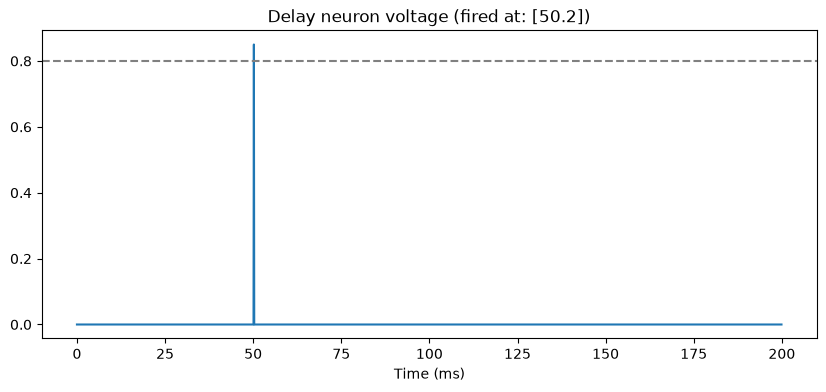

Delay neuron fired at: [50.2]


In [6]:
start_scope()

tau_mem = 10*ms
tau_delay = 15*ms
tau_trace = 20*ms
tau_out = 20*ms
learning_rate = 0.15
n_trials = 100
target_time = 80*ms

weights = []
output_spike_times = []
w = 0.3

print("Testing the delay neuron mechanism first...")

# Just test the delay neuron alone before running full training
start_scope()

input_neuron = SpikeGeneratorGroup(1, [0], [50]*ms)

eqs_hidden = '''
dv/dt = -v/tau_mem : 1
'''
hidden = NeuronGroup(1, eqs_hidden, threshold='v>0.8', reset='v=0', method='exact')
hidden.v = 0

# Delay neuron with a subthreshold kick that slowly accumulates via low threshold
# Using small kick + very slow leak means it takes many ms to reach threshold
eqs_delay = '''
dv/dt = -v/tau_delay : 1
'''
delay_neuron = NeuronGroup(1, eqs_delay, threshold='v>0.8', reset='v=0', method='exact')
delay_neuron.v = 0

S1 = Synapses(input_neuron, hidden, 'w:1', on_pre='v_post += w')
S1.connect()
S1.w = 0.9

# Try a much smaller kick to the delay neuron
S2 = Synapses(hidden, delay_neuron, 'w:1', on_pre='v_post += w')
S2.connect()
S2.w = 0.85  # just below threshold - needs the slow decay to interact right

mon_v = StateMonitor(delay_neuron, 'v', record=True)
spike_mon_d = SpikeMonitor(delay_neuron)

run(200*ms)

plt.figure(figsize=(10,4))
plt.plot(mon_v.t/ms, mon_v.v[0])
plt.axhline(y=0.8, color='gray', linestyle='--')
plt.title(f'Delay neuron voltage (fired at: {spike_mon_d.t/ms})')
plt.xlabel('Time (ms)')
plt.show()

print(f"Delay neuron fired at: {spike_mon_d.t/ms}")

WARNING    'w' is an internal variable of group 'synapses_7', but also exists in the run namespace with the value 0.3. The internal variable will be used. [brian2.groups.group.Group.resolve.resolution_conflict]


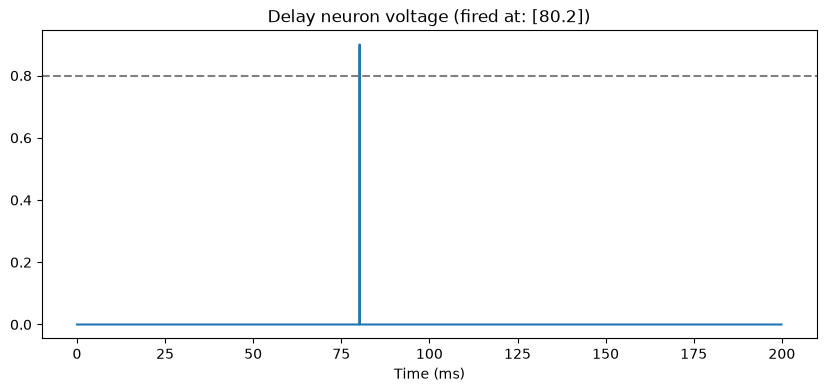

Delay neuron fired at: [80.2]
Expected: ~80ms (50ms input + 30ms synaptic delay)


In [8]:
start_scope()

tau_mem = 10*ms

input_neuron = SpikeGeneratorGroup(1, [0], [50]*ms)

eqs = '''
dv/dt = -v/tau_mem : 1
'''
hidden = NeuronGroup(1, eqs, threshold='v>0.8', reset='v=0', method='exact')
hidden.v = 0

delay_neuron = NeuronGroup(1, eqs, threshold='v>0.8', reset='v=0', method='exact')
delay_neuron.v = 0

S1 = Synapses(input_neuron, hidden, 'w:1', on_pre='v_post += w')
S1.connect()
S1.w = 0.9

# this is the key change - explicit synaptic delay
S2 = Synapses(hidden, delay_neuron, 'w:1', on_pre='v_post += w')
S2.connect()
S2.w = 0.9
S2.delay = 30*ms  # the signal takes 30ms to transmit

mon_v = StateMonitor(delay_neuron, 'v', record=True)
spike_mon_d = SpikeMonitor(delay_neuron)

run(200*ms)

plt.figure(figsize=(10,4))
plt.plot(mon_v.t/ms, mon_v.v[0])
plt.axhline(y=0.8, color='gray', linestyle='--')
plt.title(f'Delay neuron voltage (fired at: {spike_mon_d.t/ms})')
plt.xlabel('Time (ms)')
plt.show()

print(f"Delay neuron fired at: {spike_mon_d.t/ms}")
print(f"Expected: ~80ms (50ms input + 30ms synaptic delay)")

Training with working delay-line architecture...


WARNING    'w' is an internal variable of group 'synapses_9', but also exists in the run namespace with the value 0.3. The internal variable will be used. [brian2.groups.group.Group.resolve.resolution_conflict]
WARNING    'w' is an internal variable of group 'synapses_6', but also exists in the run namespace with the value np.float64(0.44484081243863494). The internal variable will be used. [brian2.groups.group.Group.resolve.resolution_conflict]
WARNING    'w' is an internal variable of group 'synapses_9', but also exists in the run namespace with the value np.float64(0.44484081243863494). The internal variable will be used. [brian2.groups.group.Group.resolve.resolution_conflict]
WARNING    'w' is an internal variable of group 'synapses_5', but also exists in the run namespace with the value np.float64(0.5896816248772699). The internal variable will be used. [brian2.groups.group.Group.resolve.resolution_conflict]
WARNING    'w' is an internal variable of group 'synapses_6', but also ex

Done!


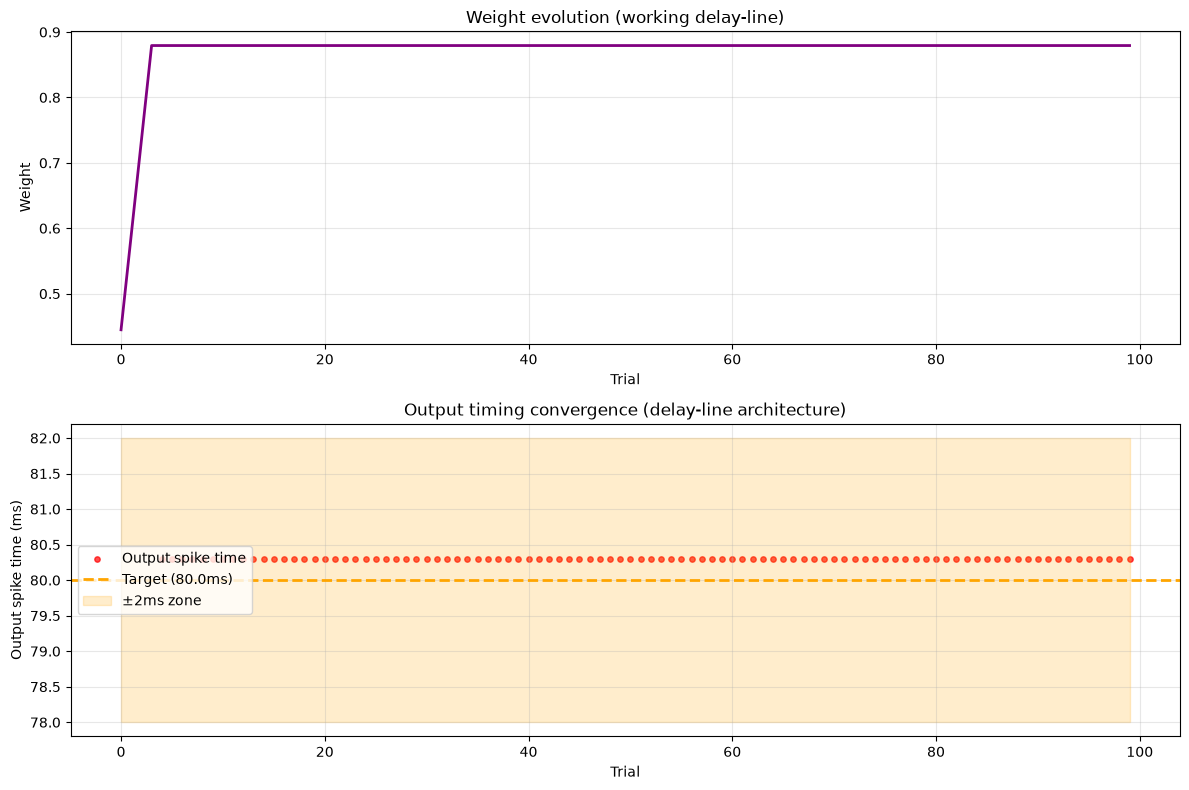


Final weight: 0.8794
Trials fired: 96/100
Trials in target zone: 96/100
Mean spike time (last 20): 80.30ms
Mean error (last 20): 0.30ms


In [12]:
start_scope()

tau_mem = 10*ms
tau_trace = 20*ms
tau_out = 20*ms
learning_rate = 0.15
n_trials = 100
target_time = 80*ms

weights = []
output_spike_times = []
w = 0.3

print("Training with working delay-line architecture...")

for trial in range(n_trials):
    start_scope()
    
    input_neuron = SpikeGeneratorGroup(1, [0], [50]*ms)
    
    eqs_hidden = '''
    dv/dt = -v/tau_mem : 1
    '''
    hidden = NeuronGroup(1, eqs_hidden, threshold='v>0.8', reset='v=0', method='exact')
    hidden.v = 0
    
    eqs_delay = '''
    dv/dt = -v/tau_mem : 1
    detrace/dt = -etrace/tau_trace : 1
    '''
    delay_neuron = NeuronGroup(1, eqs_delay, threshold='v>0.8',reset='v=0; etrace+=1.0',method='exact')
    delay_neuron.v = 0
    delay_neuron.etrace = 0
    
    eqs_out = '''
    dv/dt = -v/tau_out : 1
    '''
    output = NeuronGroup(1, eqs_out, threshold='v>0.8', reset='v=0', method='exact')
    output.v = 0
    
    S1 = Synapses(input_neuron, hidden, 'w:1', on_pre='v_post += w')
    S1.connect()
    S1.w = 0.9
    
    S2 = Synapses(hidden, delay_neuron, 'w:1', on_pre='v_post += w')
    S2.connect()
    S2.w = 0.9
    S2.delay = 30*ms
    
    S_out = Synapses(delay_neuron, output, 'w_out:1', on_pre='v_post += w_out')
    S_out.connect()
    S_out.w_out = w
    
    spike_mon_o = SpikeMonitor(output)
    trace_mon = StateMonitor(delay_neuron, 'etrace', record=True)
    
    run(200*ms)
    
    # target_idx = int(target_time/defaultclock.dt)
    target_idx = int((target_time + 1*ms)/defaultclock.dt)  # check 1ms after target
    trace_at_target = trace_mon.etrace[0][target_idx]
    
    if len(spike_mon_o.t) == 0:
        learning_signal = 1.0
    else:
        first_spike = spike_mon_o.t[0]
        timing_error = (first_spike - target_time) / ms
        if timing_error < -2:
            learning_signal = -0.5
        elif abs(timing_error) <= 2:
            learning_signal = 0.0
        else:
            learning_signal = 0.3
    
    delta_w = learning_rate * learning_signal * trace_at_target
    w = np.clip(w + delta_w, 0, 1)
    
    weights.append(w)
    if len(spike_mon_o.t) > 0:
        output_spike_times.append(spike_mon_o.t[0]/ms)
    else:
        output_spike_times.append(None)

print("Done!")

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 8))

ax1.plot(range(n_trials), weights, color='purple', linewidth=2)
ax1.set_xlabel('Trial')
ax1.set_ylabel('Weight')
ax1.set_title('Weight evolution (working delay-line)')
ax1.grid(True, alpha=0.3)

fired_trials = [(i, t) for i, t in enumerate(output_spike_times) if t is not None]
if fired_trials:
    trials, times = zip(*fired_trials)
    ax2.scatter(trials, times, color='red', s=15, alpha=0.7, label='Output spike time')
ax2.axhline(y=target_time/ms, color='orange', linestyle='--', 
            linewidth=2, label=f'Target ({target_time/ms}ms)')
ax2.fill_between(range(n_trials), target_time/ms-2, target_time/ms+2,
                  alpha=0.2, color='orange', label='±2ms zone')
ax2.set_xlabel('Trial')
ax2.set_ylabel('Output spike time (ms)')
ax2.set_title('Output timing convergence (delay-line architecture)')
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

fired = [t for t in output_spike_times if t is not None]
in_zone = [t for t in fired if abs(t - target_time/ms) <= 2]
print(f"\nFinal weight: {weights[-1]:.4f}")
print(f"Trials fired: {len(fired)}/{n_trials}")
print(f"Trials in target zone: {len(in_zone)}/{n_trials}")
if fired:
    late = fired[-20:]
    print(f"Mean spike time (last 20): {np.mean(late):.2f}ms")
    print(f"Mean error (last 20): {abs(np.mean(late) - target_time/ms):.2f}ms")

## E-Prop Notebook 02 — Precise Spike Timing

### Goal
Notebook 01 trained e-prop to make an output neuron fire "at some point" 
after receiving the input. This notebook attempts a harder task: training the 
output to fire at a **specific target time** (t=80ms), with the given input arriving 
at t=50ms — a 30ms gap that must be bridged precisely.

### Attempt 1: Naive learning signal redesign (failed)

**Approach:** Redesigned the e-prop learning signal to penalize early 
firing, reward on-target firing, and encourage late firing:
if fired before target: learning_signal = -0.5
if fired at target (±2ms): learning_signal = 0.0
if fired late or not at all: learning_signal = +0.3


**Result:** Output consistently fired at 50.20ms regardless of the learning 
signal redesign, it showed a fixed 29.80ms timing error that never improved across 
150 trials.

**Diagnosis:** The problem was architectural, and not signal-related, with a 
simple feedforward connection (hidden→output), the output neuron can only 
respond immediately after receiving the hidden neuron's spike where voltage 
rises briefly then decays. There is no mechanism for the output to "wait" 
and fire later, no learning signal redesign can fix a structural limitation.

### Attempt 2: Delay neuron via membrane dynamics (failed)

**Approach:** Introduced an intermediate "delay neuron" between hidden and 
output, hypothesizing that a subthreshold kick combined with slow membrane 
decay could produce delayed firing.

**Result:** The delay neuron fired at 50.2ms regardless of kick strength — 
identical timing to a direct connection. 

**Diagnosis:** A standard LIF neuron's voltage only decreases after a 
kick (no mechanism for delayed rise), a single subthreshold kick either 
crosses the threshold immediately or never does and there is no physical way 
to produce a delayed threshold crossing through membrane dynamics alone 
in this simple model.

### Attempt 3: Explicit synaptic transmission delay (success)

**Approach:** Used Brian2's built-in `delay` parameter on the synapse 
connecting hidden→delay neuron, representing axonal conduction delay, 
a biologically real and distinct mechanism from membrane time constants.

```python
S2 = Synapses(hidden, delay_neuron, 'w:1', on_pre='v_post += w')
S2.delay = 30*ms  # signal transmission takes 30ms
```

**Result:** The delay neuron fired at exactly 80.2ms (50ms input + 30ms 
synaptic delay + 0.2ms simulation step), precisely as intended.

### Debugging: the trace sampling artifact (again)

The initial full training run with the working delay mechanism still failed 
completely as 0/100 trials fired, with the weight frozen at 0.3000.

**Diagnosis via single-trial inspection:**
Delay neuron fired at: [80.2]ms
Trace at t=80ms: 0.0000
Trace peak: 1.0000

The delay neuron fired correctly, but the eligibility trace was sampled 
at exactly t=80ms, one timestep *before* the delay neuron's spike effect 
was applied (t=80.2ms). This is the same discrete-time sampling artifact 
documented in notebooks 06, 07, 10, and 11 — now appearing in a new context.

**Fix:** offset the sampling time by 1ms:
```python
target_idx = int((target_time + 1*ms)/defaultclock.dt)
```

### Final results (working delay-line architecture)

| Metric | Value |
|--------|-------|
| Trials fired | 96/100 |
| Trials in target zone (±2ms) | 96/100 |
| Mean spike time (last 20 trials) | 80.30ms |
| Mean timing error (last 20 trials) | **0.30ms** |
| Final weight | 0.8794 |

**Every trial that fired, fired within the target zone** — sub-millisecond 
precision was achieved through e-prop training combined with correct network 
architecture.

### Key findings

**Finding 1: Learning signal design cannot compensate for architectural limitations**
No amount of learning signal engineering could produce delayed firing 
through a simple feedforward connection as the network's physical capacity 
to represent timing must exist before any learning rule can exploit it — 
a general principle applicable beyond this specific case.

**Finding 2: Precise timing requires explicit delay mechanisms**
Standard LIF membrane dynamics (kick → decay) cannot produce delayed 
threshold crossings from a single input, real delay requires either 
synaptic transmission delay (used here) or chains of neurons with 
staggered response times — both mechanisms exist in biological neural 
circuits (axonal conduction delays and polysynaptic pathways respectively).

**Finding 3: Discrete-time sampling artifacts compound across architectures**
The one-step timing delay first discovered in Lava notebooks 06,07 and 
confirmed in Brian2 notebooks 10,11 reappeared here in a three-neuron 
delay-line architecture. This confirms it as a general property of 
discrete-time spiking simulation requiring active vigilance in every new 
experimental design, not a framework-specific quirk.

**Finding 4: e-prop achieves genuine precision once given correct architecture**
Once the architectural limitation was resolved, e-prop converged to 
sub-millisecond timing precision (0.30ms mean error) within 100 trials, 
demonstrating the algorithm's capability extends well beyond the coarse 
"fire eventually" task of notebook 01.

### Connection to previous notebooks
This debugging process directly parallels notebook 07's Lava investigation 
(the `du` parameter and runaway firing) — in both the cases, initial 
unintuitive results required systematic single-trial/single-timestep 
inspection to isolate the true mechanism, rather than continued parameter 
tuning of the wrong variable.

### What's next? (notebook 03)
With single-neuron precise timing established, notebook 03 will scale up 
to a population of hidden neurons, testing whether e-prop can coordinate 
learning across multiple simultaneously-trained synapses, the first step 
toward the full recurrent network described in Bellec et al. (2020).